In [1]:
import numpy as np

X2_train = np.load("../models/X2_train.npy")
X2_test  = np.load("../models/X2_test.npy")
y2_train = np.load("../models/y2_train.npy")
y2_test  = np.load("../models/y2_test.npy")

print("Train shape:", X2_train.shape, y2_train.shape)
print("Test shape:", X2_test.shape, y2_test.shape)


Train shape: (59793, 48, 10) (59793, 6, 2)
Test shape: (14949, 48, 10) (14949, 6, 2)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping

model2 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X2_train.shape[1], X2_train.shape[2])),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(6 * 2),
    Reshape((6, 2))
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
model2.summary()


d:\Aditya\Projects\SDP\AquaCulture\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 2)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,356 (474.05 KB)

 Trainable params: 121,356 (474.05 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

history2 = model2.fit(
    X2_train, y2_train,
    validation_split=0.2,
    epochs=60,
    batch_size=128,
    callbacks=[early_stop]
)


Epoch 1/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 47s 119ms/step - loss: 0.0092 - mae: 0.0657 - val_loss: 0.0077 - val_mae: 0.0563
Epoch 2/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - loss: 0.0074 - mae: 0.0576 - val_loss: 0.0077 - val_mae: 0.0561
Epoch 3/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - loss: 0.0071 - mae: 0.0558 - val_loss: 0.0076 - val_mae: 0.0558
Epoch 4/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - loss: 0.0069 - mae: 0.0545 - val_loss: 0.0078 - val_mae: 0.0583
Epoch 5/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - loss: 0.0067 - mae: 0.0537 - val_loss: 0.0077 - val_mae: 0.0565
Epoch 6/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - loss: 0.0066 - mae: 0.0529 - val_loss: 0.0073 - val_mae: 0.0545
Epoch 7/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - loss: 0.0064 - mae: 0.0521 - val_loss: 0.0070 - val_mae: 0.0536
Epoch 8/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - loss: 0.0061 - mae: 0.0510 - val_loss: 0.0067 - val_mae: 0.0525
Epoch 9/60
374/374 ━━━━━━━━━━━━━━━━━━━━

In [4]:
test_loss2, test_mae2 = model2.evaluate(X2_test, y2_test)
print("Model 2 Test MSE:", test_loss2)
print("Model 2 Test MAE:", test_mae2)

468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0074 - mae: 0.0535
Model 2 Test MSE: 0.007387453690171242
Model 2 Test MAE: 0.05348269268870354


In [5]:
y2_pred = model2.predict(X2_test)
print("Predicted shape:", y2_pred.shape)

468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
Predicted shape: (14949, 6, 2)


In [6]:
model2.save("../models/model2_nitrogen_lstm.keras")

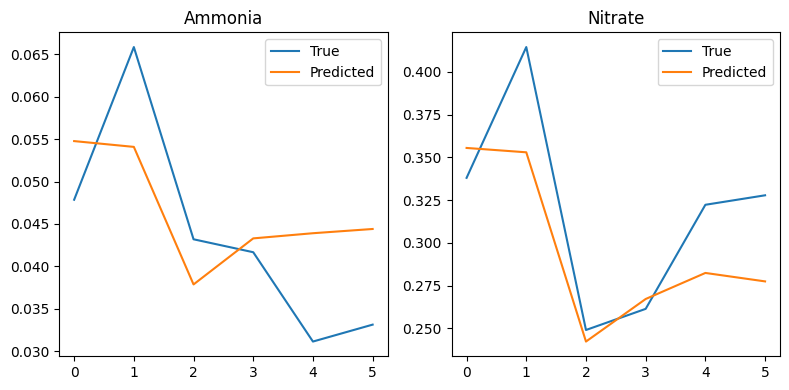

In [7]:
import matplotlib.pyplot as plt

params2 = ["Ammonia", "Nitrate"]

sample = 10

true_vals = y2_test[sample]
pred_vals = y2_pred[sample]

plt.figure(figsize=(8,4))
for i in range(2):
    plt.subplot(1,2,i+1)
    plt.plot(true_vals[:,i], label='True')
    plt.plot(pred_vals[:,i], label='Predicted')
    plt.title(params2[i])
    plt.legend()

plt.tight_layout()
plt.show()


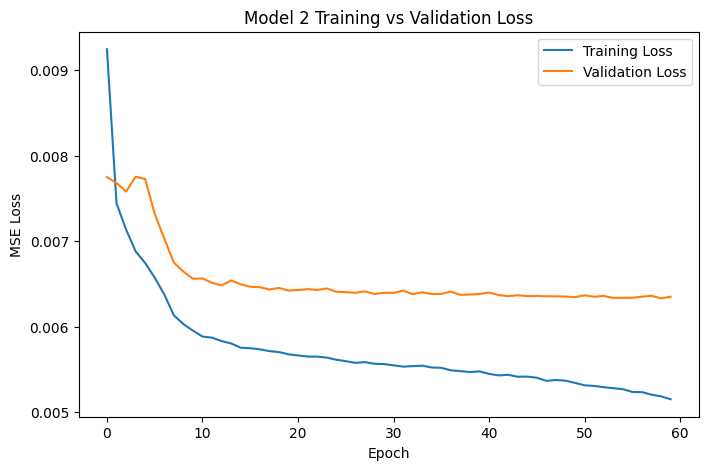

In [8]:
# Training vs Validation Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model 2 Training vs Validation Loss')
plt.legend()
plt.show()


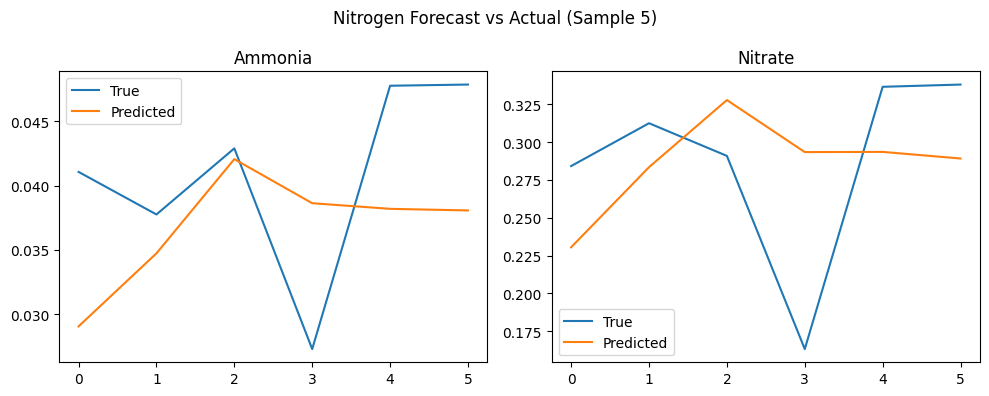

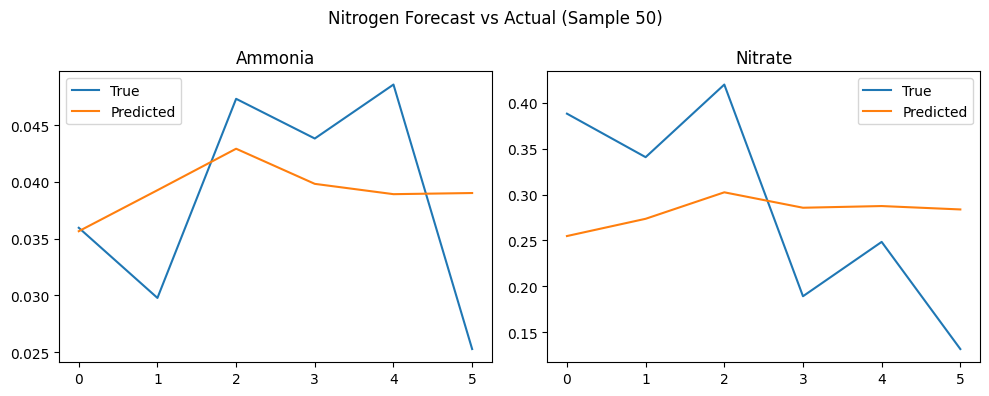

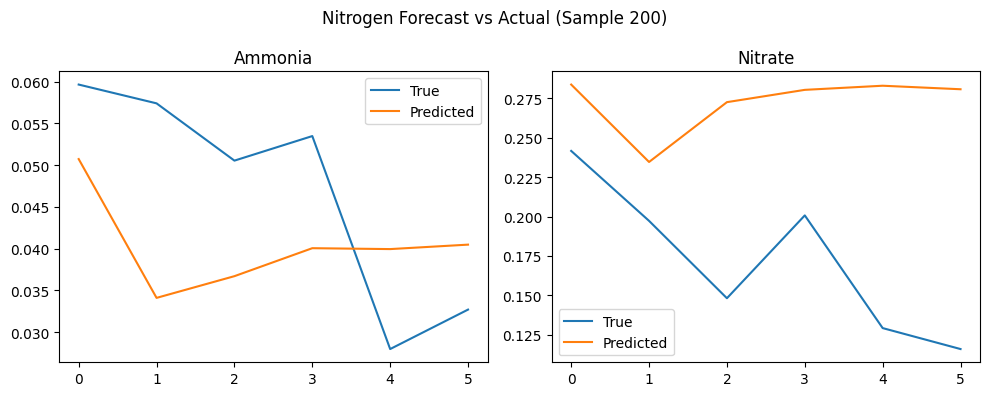

In [9]:
# Multi-Step Forecast Examples
params2 = ["Ammonia", "Nitrate"]
samples_to_plot = [5, 50, 200]

for sample in samples_to_plot:
    plt.figure(figsize=(10,4))
    true_vals = y2_test[sample]
    pred_vals = y2_pred[sample]

    for i in range(2):
        plt.subplot(1,2,i+1)
        plt.plot(true_vals[:,i], label='True')
        plt.plot(pred_vals[:,i], label='Predicted')
        plt.title(params2[i])
        plt.legend()

    plt.suptitle(f"Nitrogen Forecast vs Actual (Sample {sample})")
    plt.tight_layout()
    plt.show()


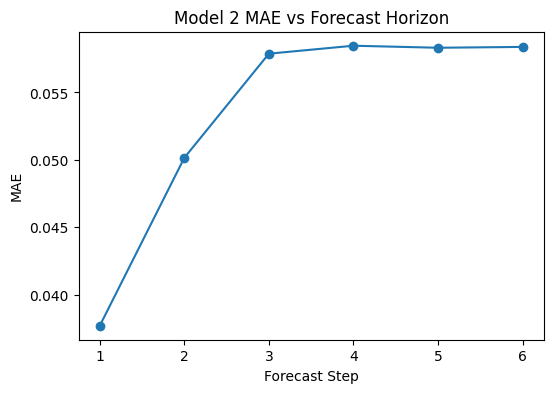

In [10]:
# MAE per Forecast Horizon Step
mae_per_step2 = np.mean(np.abs(y2_test - y2_pred), axis=(0,2))

plt.figure(figsize=(6,4))
plt.plot(range(1,7), mae_per_step2, marker='o')
plt.title("Model 2 MAE vs Forecast Horizon")
plt.xlabel("Forecast Step")
plt.ylabel("MAE")
plt.show()


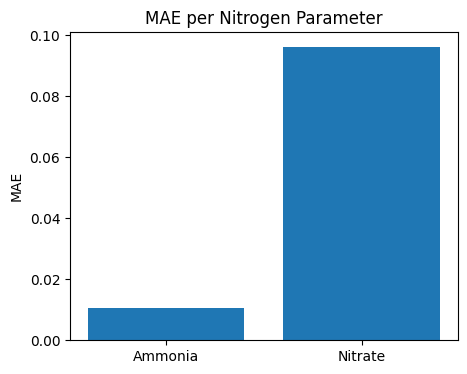

In [11]:
# Parameter-wise MAE
mae_per_param2 = np.mean(np.abs(y2_test - y2_pred), axis=(0,1))

plt.figure(figsize=(5,4))
plt.bar(params2, mae_per_param2)
plt.title("MAE per Nitrogen Parameter")
plt.ylabel("MAE")
plt.show()


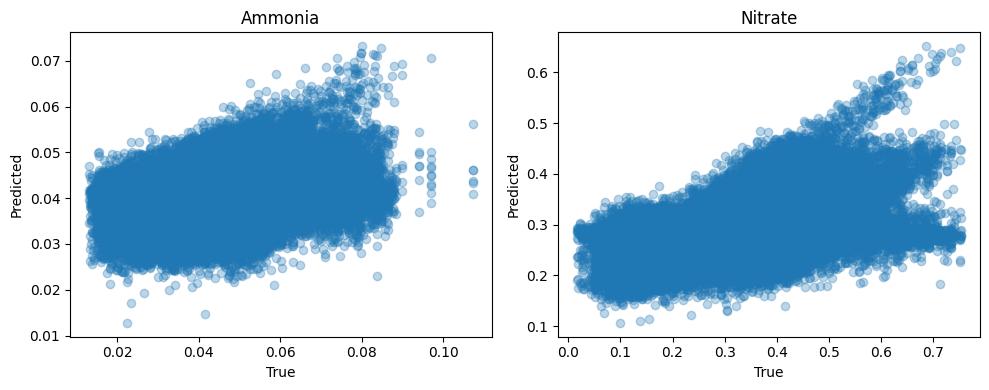

In [12]:
# Scatter Plot (True vs Predicted)

plt.figure(figsize=(10,4))

for i, param in enumerate(params2):
    plt.subplot(1,2,i+1)
    plt.scatter(y2_test[:,:,i].flatten(), y2_pred[:,:,i].flatten(), alpha=0.3)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(param)

plt.tight_layout()
plt.show()


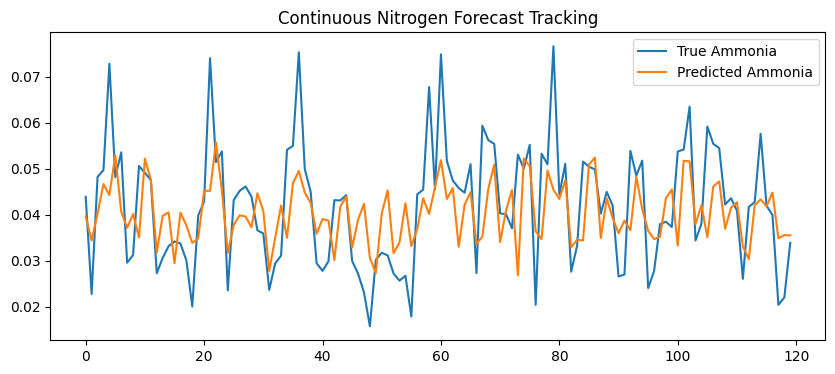

In [13]:
# Continuous Time Tracking
start = 1000
length = 120

true_segment = y2_test[start:start+length, 0, 0]   # Ammonia at first future step
pred_segment = y2_pred[start:start+length, 0, 0]

plt.figure(figsize=(10,4))
plt.plot(true_segment, label="True Ammonia")
plt.plot(pred_segment, label="Predicted Ammonia")
plt.title("Continuous Nitrogen Forecast Tracking")
plt.legend()
plt.show()
